# Long Short-Term Memory (LSTM) for Wind Speed Forecasting
## Dataset 1

This notebook implements LSTM-based wind speed forecasting with four modelling strategies:
1. **Original Model** – Manually specified architecture (no tuning)
2. **Grid Search** – Exhaustive hyperparameter search with TimeSeriesSplit CV via scikeras
3. **Randomized Search** – Stochastic hyperparameter search with TimeSeriesSplit CV via scikeras
4. **Optuna** – TPE-based Bayesian hyperparameter optimisation with TimeSeriesSplit CV

**Key design decisions:**
- First 80% of observations → training; last 20% → testing (chronological, no shuffling)
- Hyperparameter tuning is performed **exclusively on training data** using `TimeSeriesSplit` (5 folds)
- `StandardScaler` is **fit on training data only** and reused across ALL sections — prevents data leakage
- LSTM input shape: `(samples, timesteps=1, features)` — single-step formulation
- `shuffle=False` in all `.fit()` calls — preserves temporal ordering
- Global random seed: **42**

# ─────────────────────────────────────────
# SECTION 0 — PACKAGE INSTALLATION
# ─────────────────────────────────────────

In [1]:
!pip install -U scikit-learn scikeras

!pip install scikeras

import sklearn
import scikeras

print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
#scikit-learn >= 1.2.0
#scikeras >= 0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
scikit-learn version: 1.8.0
scikeras version: 0.13.0


In [2]:
# Install required packages (run once)
!pip install statsmodels optuna tabulate scikeras --quiet
!pip install tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.9 MB/s eta 0:00:00


In [3]:
! pip instal optuna

ERROR: unknown command "instal" - maybe you meant "install"


# ─────────────────────────────────────────
# SECTION 1 — IMPORTS & GLOBAL SETTINGS
# ─────────────────────────────────────────

In [4]:
# Standard libraries
import sys
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.inspection import permutation_importance

# Scipy — statistical distributions for RandomizedSearchCV
from scipy.stats import randint, uniform

# TensorFlow / Keras — LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# scikeras — scikit-learn wrapper for Keras models
from scikeras.wrappers import KerasRegressor

# Optuna — Bayesian hyperparameter optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress verbose trial logs

# Tabulate — pretty-print summary tables
from tabulate import tabulate

# ── Global random seed (reproducibility) ──
# Set seed for Python, NumPy, and TensorFlow to ensure reproducible results
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f'Random seed set to: {RANDOM_SEED}')
print(f'TensorFlow version : {tf.__version__}')

Random seed set to: 42
TensorFlow version : 2.19.0


# ─────────────────────────────────────────
# SECTION 2 — DATA LOADING
# ─────────────────────────────────────────

In [5]:
# Load dataset from Google Drive
# Source: https://drive.google.com/file/d/1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk
file_id = '1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk'
download_url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(download_url)

# Backup original DataFrame before any transformation
df_backup = df.copy()

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})
df = df.set_index('Date')

# Drop raw date component columns (now encoded in the index)
df = df.drop(columns=['YEAR', 'MO', 'DY'])

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (4015, 14)
Columns: ['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66


# ─────────────────────────────────────────
# SECTION 3 — TRAIN / TEST SPLIT
# ─────────────────────────────────────────

In [6]:
# Target variable: wind speed at 10 m (WS10M)
# Features: all remaining meteorological predictors

X = df.drop(columns=['WS10M'])   # Feature matrix
y = df['WS10M']                  # Target vector

# ── Chronological 80/20 split — NO random shuffling (time series integrity) ──
split_index = int(len(X) * 0.8)  # 80% train, 20% test

X_train = X.iloc[:split_index]   # Training features
y_train = y.iloc[:split_index]   # Training target

X_test  = X.iloc[split_index:]   # Testing features
y_test  = y.iloc[split_index:]   # Testing target

print(f'Total samples : {len(df)}')
print(f'Training set  : {X_train.shape[0]} samples ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Testing set   : {X_test.shape[0]}  samples ({X_test.index[0].date()} → {X_test.index[-1].date()})')

Total samples : 4015
Training set  : 3212 samples (2013-01-03 → 2021-10-19)
Testing set   : 803  samples (2021-10-20 → 2023-12-31)


# ─────────────────────────────────────────
# SECTION 4 — FEATURE SCALING & LSTM RESHAPING
# ─────────────────────────────────────────

In [7]:

# ── IMPORTANT: Scaler is fit on TRAINING DATA ONLY to prevent data leakage ──
# The same scaler parameters (mean, std) are applied to the test set.
# This single scaler instance is reused across ALL four modelling sections.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, then transform
X_test_scaled  = scaler.transform(X_test)        # Transform test using train statistics only

# ── Reshape for LSTM: (samples, timesteps=1, features) ──
# timesteps=1 corresponds to a single-step (non-sequence) formulation.
# Each row becomes one time step with all features as input channels.
X_train_lstm = np.expand_dims(X_train_scaled, axis=1)  # Shape: (n_train, 1, n_features)
X_test_lstm  = np.expand_dims(X_test_scaled,  axis=1)  # Shape: (n_test,  1, n_features)

# ── Targets as flat numpy arrays (LSTM output is 1D regression) ──
y_train_arr = y_train.values.flatten()
y_test_arr  = y_test.values.flatten()

n_features = X_train_lstm.shape[2]  # Stored for model building

print('Scaling and reshaping complete.')
print(f'X_train_lstm shape : {X_train_lstm.shape}')
print(f'X_test_lstm  shape : {X_test_lstm.shape}')
print(f'Number of features : {n_features}')

Scaling and reshaping complete.
X_train_lstm shape : (3212, 1, 13)
X_test_lstm  shape : (803, 1, 13)
Number of features : 13


# ─────────────────────────────────────────
# SECTION 5 — HELPER FUNCTIONS
# ─────────────────────────────────────────

In [8]:
def evaluate_metrics(y_true, y_pred, label=''):
    """
    Compute and print regression performance metrics.

    Parameters
    ----------
    y_true : array-like  — Ground-truth target values
    y_pred : array-like  — Model predictions
    label  : str         — Prefix label for printed output

    Returns
    -------
    Tuple: (MSE, RMSE, MAE, MAPE, R²)
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # MAPE: guard against division by zero using np.where
    mape = np.mean(
        np.where(np.abs(y_true) > 1e-8,
                 np.abs((y_true - y_pred) / y_true) * 100,
                 0.0)
    )
    r2   = r2_score(y_true, y_pred)

    print(f'{label} MSE  : {mse:.4f}')
    print(f'{label} RMSE : {rmse:.4f}')
    print(f'{label} MAE  : {mae:.4f}')
    print(f'{label} MAPE : {mape:.2f}%')
    print(f'{label} R²   : {r2:.4f}')
    return mse, rmse, mae, mape, r2


def plot_actual_vs_predicted(y_true, y_pred, title, color='blue'):
    """
    Line plot of actual vs predicted values on the test set.

    Parameters
    ----------
    y_true : array-like — Actual target values
    y_pred : array-like — Predicted target values
    title  : str        — Plot title
    color  : str        — Line colour for predictions
    """
    plt.figure(figsize=(12, 5))
    plt.plot(np.array(y_true).flatten(), label='Actual',    color='black', linewidth=2)
    plt.plot(np.array(y_pred).flatten(), label='Predicted', color=color,   linewidth=2, linestyle='--')
    plt.title(title, fontsize=13)
    plt.xlabel('Observation Index')
    plt.ylabel('Wind Speed (WS10M)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_training_history(history, title='LSTM Training History'):
    """
    Plot training and validation loss curves.

    Parameters
    ----------
    history : keras History object — returned by model.fit()
    title   : str                  — Plot title
    """
    plt.figure(figsize=(9, 4))
    plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    plt.title(title, fontsize=13)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Storage dictionary for the final comparison table
results_store = {}

print('Helper functions defined.')

Helper functions defined.


# ─────────────────────────────────────────
# SECTION 6 — LSTM: ORIGINAL MODEL
#             (No hyperparameter optimisation)
# ─────────────────────────────────────────

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,851 (50.20 KB)

 Trainable params: 12,851 (50.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 19.2337 - val_loss: 16.3055
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.1742 - val_loss: 7.5762
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.7878 - val_loss: 2.6249
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2989 - val_loss: 1.4382
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3465 - val_loss: 1.1124
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0254 - val_loss: 0.9631
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8622 - val_loss: 0.8619
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7483 - val_loss: 0.7833
Epoch 9/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6605 - val_loss: 0.7217
Epoch 10/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5935 - val_loss: 0.6763
Epoch 11/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5450 - val_loss: 0.6451
Epoch 12/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

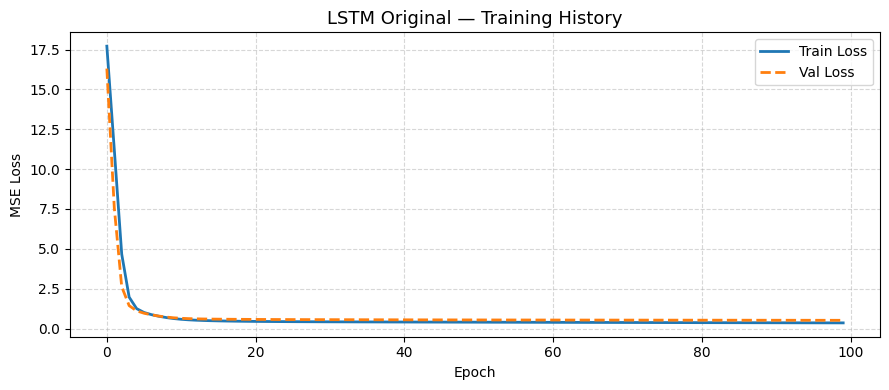

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
  LSTM — ORIGINAL MODEL (Default Parameters)

[Training Set]
Train MSE  : 0.3663
Train RMSE : 0.6053
Train MAE  : 0.4732
Train MAPE : 12.81%
Train R²   : 0.8546

[Test Set]
Test  MSE  : 0.5919
Test  RMSE : 0.7694
Test  MAE  : 0.5943
Test  MAPE : 15.50%
Test  R²   : 0.7545

First 20 test predictions:
            Actual  Predicted
Date                         
2021-10-20    2.82   3.547431
2021-10-21    2.79   3.237447
2021-10-22    2.72   2.421080
2021-10-23    4.30   2.509242
2021-10-24    3.74   3.182901
2021-10-25    2.69   3.415492
2021-10-26    2.37   3.358165
2021-10-27    2.30   2.458440
2021-10-28    3.50   3.360060
2021-10-29    4.15   3.313588
2021-10-30    1.97   3.160000
2021-10-31    5.60   4.268657
2021-11-01    6.11   3.866641
2021-11-02    2.57   4.036925
2021-11-03    3.27   3.601038
2021-11-04    3.36   2.879549
2021-11-05    3.55   3.212236
2021-11-06    4.03   4.259870
2021-11-07    5.18

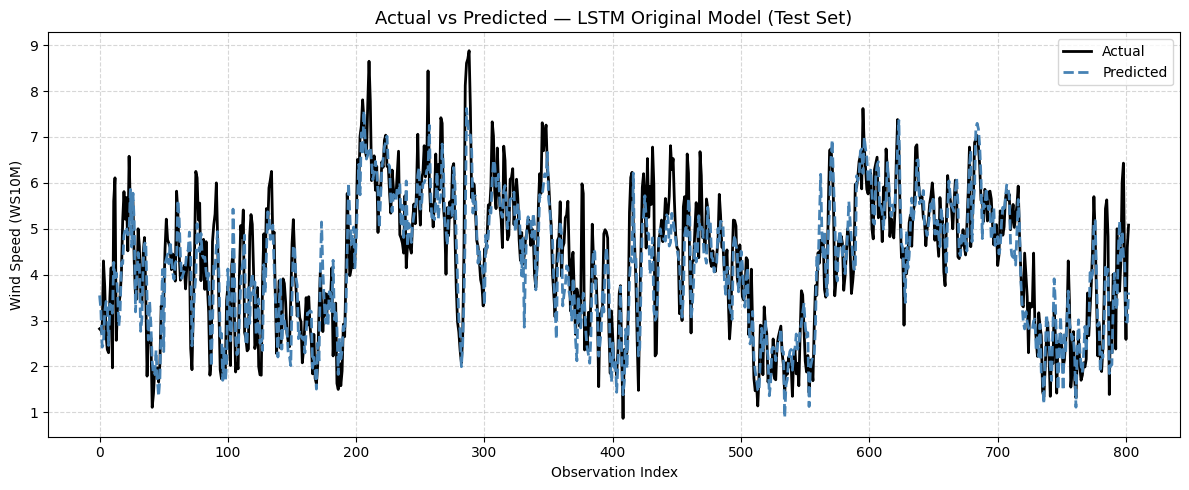

In [9]:
# ── LSTM with manually specified default architecture ──
# 50 LSTM units with tanh activation (standard for LSTM gates)
# Adam optimiser with learning_rate=0.001 (widely used default)
# validation_split=0.1 uses the LAST 10% of training data as validation
# shuffle=False is CRITICAL — preserves the temporal order of samples

tf.random.set_seed(RANDOM_SEED)

lstm_original = Sequential([
    LSTM(50, activation='tanh',
         input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)   # Single output neuron for regression
])
lstm_original.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_original.summary()

# Train the model
# shuffle=False: CRITICAL for time series — must not mix future into past
history_orig = lstm_original.fit(
    X_train_lstm, y_train_arr,
    epochs=100,
    batch_size=32,
    validation_split=0.1,   # Last 10% of train used for validation monitoring
    shuffle=False,           # Preserve temporal ordering
    verbose=1
)

# Plot training loss curves
plot_training_history(history_orig, title='LSTM Original — Training History')

# Predict on both splits
y_train_pred_orig = lstm_original.predict(X_train_lstm).flatten()
y_test_pred_orig  = lstm_original.predict(X_test_lstm).flatten()

# ── Performance Evaluation ──
print('=' * 50)
print('  LSTM — ORIGINAL MODEL (Default Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train_arr, y_train_pred_orig, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test_arr, y_test_pred_orig, label='Test ')

# Store results for summary table
results_store['Original Model'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# Comparison DataFrame — first 20 predictions
comparison_df = pd.DataFrame({
    'Actual'   : y_test_arr,
    'Predicted': y_test_pred_orig
}, index=y_test.index)
print('\nFirst 20 test predictions:')
print(comparison_df.head(20))

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test_arr, y_test_pred_orig,
    title='Actual vs Predicted — LSTM Original Model (Test Set)',
    color='steelblue'
)

# ─────────────────────────────────────────
# SECTION 7 — LSTM: GRID SEARCH
#             (Exhaustive hyperparameter search)
# ─────────────────────────────────────────

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters (Grid Search):
{'batch_size': 32, 'epochs': 100, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__units': 128}
Best CV Score (neg-MSE): -0.4814

  LSTM — GRID SEARCH (Optimised Parameters)

[Training Set]
Train MSE  : 0.3658
Train RMSE : 0.6048
Train MAE  : 0.4741
Train MAPE : 13.16%
Train R²   : 0.8548

[Test Set]
Test  MSE  : 0.5308
Test  RMSE : 0.7286
Test  MAE  : 0.5667
Test  MAPE : 15.13%
Test  R²   : 0.7799


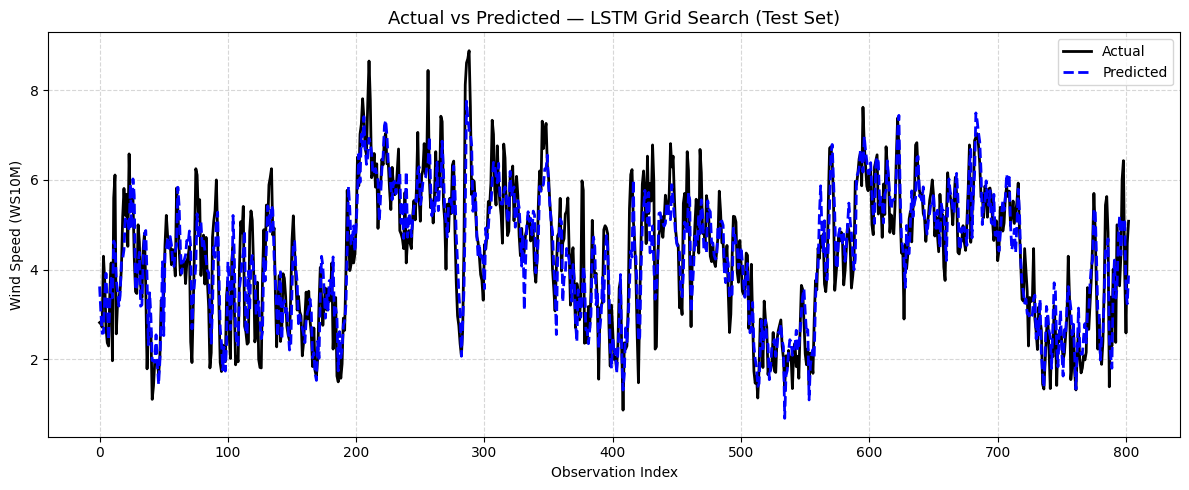

In [10]:
# ── Model builder function for scikeras ──
# scikeras requires a callable that accepts hyperparameters and returns a compiled model.
def build_lstm_grid(units=64, dropout_rate=0.2, learning_rate=0.001):
    """
    Build and compile an LSTM model for use with KerasRegressor (scikeras).

    Parameters
    ----------
    units         : int   — Number of LSTM units
    dropout_rate  : float — Dropout rate after LSTM layer
    learning_rate : float — Adam optimiser learning rate
    """
    tf.random.set_seed(RANDOM_SEED)
    model = Sequential([
        LSTM(units, activation='tanh', return_sequences=False,
             input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Wrap Keras model for scikit-learn compatibility via scikeras
lstm_regressor_grid = KerasRegressor(
    model=build_lstm_grid,
    verbose=0,
    random_state=RANDOM_SEED
)

# ── Hyperparameter grid for exhaustive search ──
param_grid = {
    'model__units'        : [32, 64, 128],
    'model__dropout_rate' : [0.1, 0.2, 0.3],
    'model__learning_rate': [0.001, 0.005],
    'batch_size'          : [16, 32],
    'epochs'              : [50, 100]
}

# ── TimeSeriesSplit: 5-fold CV applied to TRAINING DATA ONLY ──
# Ensures future observations never appear in a validation fold during tuning.
# NOTE: standard GridSearchCV with cv=3 (KFold) was in the original code —
# that randomly splits time series data and causes data leakage.
# Replaced with TimeSeriesSplit for methodological correctness.
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=lstm_regressor_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=1   # n_jobs=1 required for TF/Keras models (GPU thread safety)
)

# Fit Grid Search on LSTM-shaped training data only
grid_search.fit(X_train_lstm, y_train_arr)

print('\nBest Parameters (Grid Search):')
print(grid_search.best_params_)
print(f'Best CV Score (neg-MSE): {grid_search.best_score_:.4f}')

# ── Predict using best estimator refitted on full training set ──
best_lstm_grid = grid_search.best_estimator_
y_train_pred_grid = best_lstm_grid.predict(X_train_lstm).flatten()
y_test_pred_grid  = best_lstm_grid.predict(X_test_lstm).flatten()

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  LSTM — GRID SEARCH (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train_arr, y_train_pred_grid, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test_arr, y_test_pred_grid, label='Test ')

# Store results for summary table
results_store['Grid Search'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test_arr, y_test_pred_grid,
    title='Actual vs Predicted — LSTM Grid Search (Test Set)',
    color='blue'
)

# ─────────────────────────────────────────
# SECTION 8 — LSTM: RANDOMIZED SEARCH
#             (Stochastic hyperparameter search)
# ─────────────────────────────────────────

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters (Randomized Search):
{'batch_size': 62, 'epochs': 84, 'model__dropout_rate': np.float64(0.37279612062363465), 'model__learning_rate': np.float64(0.002429019834400152), 'model__units': 123}
Best CV Score (neg-MSE): -0.4827

  LSTM — RANDOMIZED SEARCH (Optimised Parameters)

[Training Set]
Train MSE  : 0.3778
Train RMSE : 0.6147
Train MAE  : 0.4805
Train MAPE : 13.23%
Train R²   : 0.8500

[Test Set]
Test  MSE  : 0.5308
Test  RMSE : 0.7286
Test  MAE  : 0.5631
Test  MAPE : 14.99%
Test  R²   : 0.7799


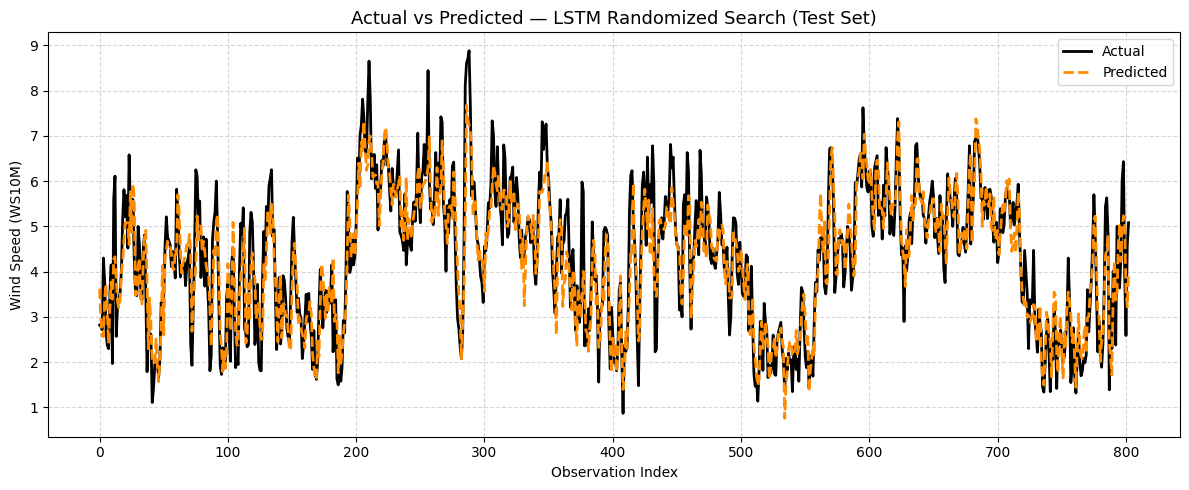

In [11]:
# ── Model builder function for scikeras ──
def build_lstm_random(units=50, dropout_rate=0.2, learning_rate=0.001):
    """
    Build and compile an LSTM model for use with KerasRegressor (scikeras).

    Parameters
    ----------
    units         : int   — Number of LSTM units
    dropout_rate  : float — Dropout rate after LSTM layer
    learning_rate : float — Adam optimiser learning rate
    """
    tf.random.set_seed(RANDOM_SEED)
    model = Sequential([
        LSTM(units, input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)   # Regression output
    ])
    model.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))
    return model

# Wrap Keras model for scikit-learn compatibility via scikeras
lstm_regressor_random = KerasRegressor(
    model=build_lstm_random,
    verbose=0,
    random_state=RANDOM_SEED
)

# ── Continuous and discrete distributions for random sampling ──
param_dist = {
    'model__units'        : randint(20, 151),          # Uniform integer in [20, 150]
    'model__dropout_rate' : uniform(0.1, 0.3),         # Continuous in [0.1, 0.4]
    'model__learning_rate': uniform(1e-4, 9e-3),       # Continuous in [0.0001, 0.0091]
    'batch_size'          : randint(16, 65),            # Uniform integer in [16, 64]
    'epochs'              : randint(50, 151)            # Uniform integer in [50, 150]
}

# ── TimeSeriesSplit: 5-fold CV applied to TRAINING DATA ONLY ──
# Original code used cv=3 (KFold) which randomly shuffles time series — data leakage.
# Replaced with TimeSeriesSplit for methodological correctness.
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=lstm_regressor_random,
    param_distributions=param_dist,
    n_iter=20,                      # Number of random parameter combinations to try
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=1    # n_jobs=1 required for TF/Keras models (GPU thread safety)
)

# Fit Randomized Search on LSTM-shaped training data only
random_search.fit(X_train_lstm, y_train_arr)

print('\nBest Parameters (Randomized Search):')
print(random_search.best_params_)
print(f'Best CV Score (neg-MSE): {random_search.best_score_:.4f}')

# ── Predict using best estimator refitted on full training set ──
best_lstm_random = random_search.best_estimator_
y_train_pred_random = best_lstm_random.predict(X_train_lstm).flatten()
y_test_pred_random  = best_lstm_random.predict(X_test_lstm).flatten()

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  LSTM — RANDOMIZED SEARCH (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train_arr, y_train_pred_random, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test_arr, y_test_pred_random, label='Test ')

# Store results for summary table
results_store['Randomized Search'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test_arr, y_test_pred_random,
    title='Actual vs Predicted — LSTM Randomized Search (Test Set)',
    color='darkorange'
)

# ─────────────────────────────────────────
# SECTION 9 — LSTM: OPTUNA
#             (TPE-based Bayesian optimisation)
# ─────────────────────────────────────────


Best Trial:
  Value (mean CV RMSE): 0.6994

Best Parameters (Optuna):
{'units': 97, 'dropout_rate': 0.1185801650879991, 'learning_rate': 0.0016409286730647919, 'batch_size': 64, 'epochs': 147}
Epoch 1/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 19.4617 - val_loss: 16.9195
Epoch 2/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.6714 - val_loss: 7.0426
Epoch 3/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0571 - val_loss: 1.8119
Epoch 4/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7034 - val_loss: 1.2074
Epoch 5/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2281 - val_loss: 1.0014
Epoch 6/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9761 - val_loss: 0.8731
Epoch 7/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8425 - val_loss: 0.7746
Epoch 8/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7119 - val_loss: 0.7069
Epoch 9/147
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6472 - val_loss: 0.6611
Epoch 10/147
46/46 ━━━━━━━━━━━━━━━━━━

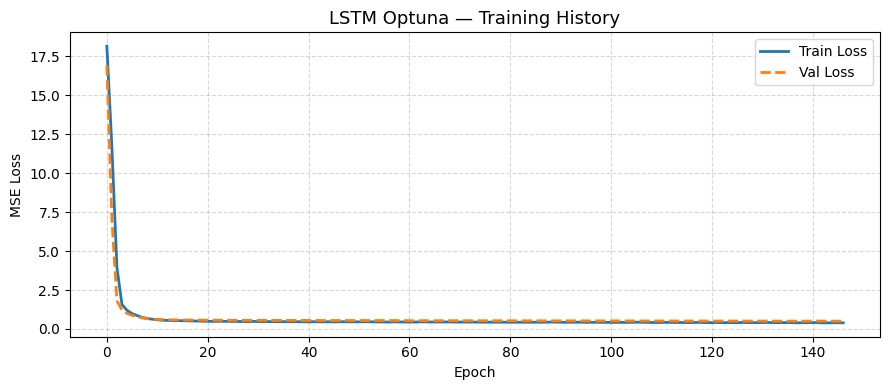

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

  LSTM — OPTUNA (Optimised Parameters)

[Training Set]
Train MSE  : 0.3567
Train RMSE : 0.5972
Train MAE  : 0.4662
Train MAPE : 12.67%
Train R²   : 0.8584

[Test Set]
Test  MSE  : 0.5607
Test  RMSE : 0.7488
Test  MAE  : 0.5781
Test  MAPE : 15.21%
Test  R²   : 0.7675


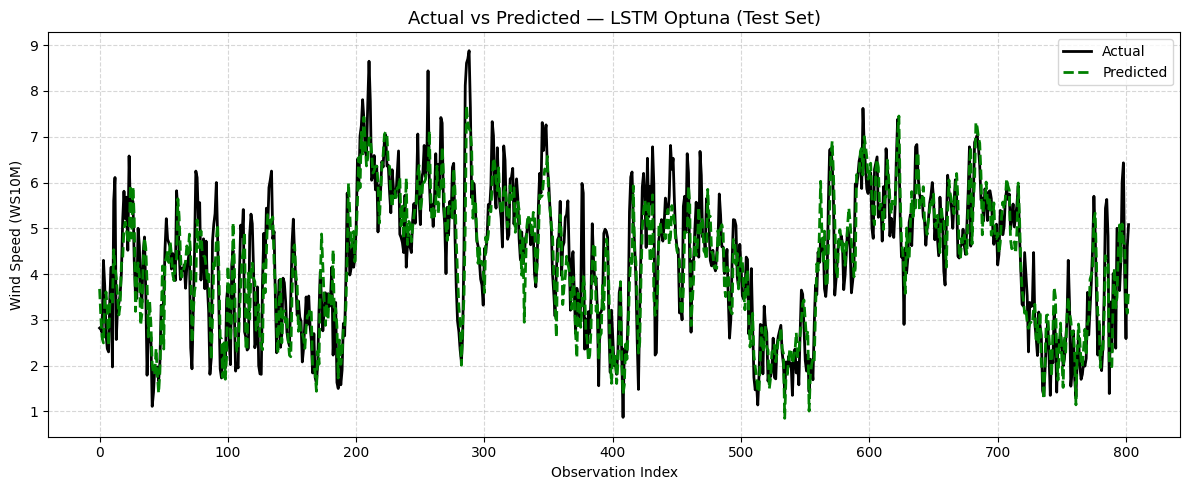

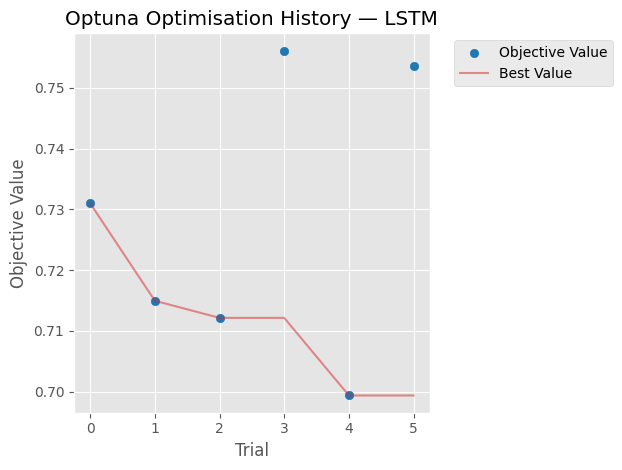

In [12]:
# ── Optuna objective function ──
# Performs TimeSeriesSplit CV on TRAINING DATA ONLY.
# Test data is NEVER touched during optimisation — no data leakage.

def lstm_objective(trial):
    # Suggest hyperparameters for this trial
    units         = trial.suggest_int('units',      20, 150)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs        = trial.suggest_int('epochs', 50, 150)

    tscv = TimeSeriesSplit(n_splits=5)
    fold_rmse = []

    for train_idx, val_idx in tscv.split(X_train_lstm):
        # ── Index into pre-scaled, pre-reshaped numpy arrays ──
        # No re-fitting of the scaler inside CV folds (would leak val statistics).
        X_fold_tr,  X_fold_val  = X_train_lstm[train_idx], X_train_lstm[val_idx]
        y_fold_tr,  y_fold_val  = y_train_arr[train_idx],  y_train_arr[val_idx]

        tf.random.set_seed(RANDOM_SEED)
        model = Sequential([
            LSTM(units, activation='tanh',
                 input_shape=(1, n_features)),
            Dropout(dropout_rate),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

        # shuffle=False: preserves temporal ordering within each fold
        model.fit(
            X_fold_tr, y_fold_tr,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            shuffle=False
        )

        preds = model.predict(X_fold_val, verbose=0).flatten()
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, preds)))

    return np.mean(fold_rmse)   # Minimise mean RMSE across folds


# ── Run Optuna study ──
# TPE (Tree-structured Parzen Estimator) sampler is more sample-efficient
# than a purely random sampler and is the recommended Optuna default.
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(lstm_objective, n_trials=30, timeout=600)  # Max 30 trials or 10 min

print('\nBest Trial:')
print(f'  Value (mean CV RMSE): {study.best_trial.value:.4f}')
print('\nBest Parameters (Optuna):')
print(study.best_params)

# ── Refit final LSTM on FULL training set using best hyperparameters ──
best_params = study.best_params

tf.random.set_seed(RANDOM_SEED)
best_lstm_optuna = Sequential([
    LSTM(best_params['units'], activation='tanh',
         input_shape=(1, n_features)),
    Dropout(best_params['dropout_rate']),
    Dense(1)
])
best_lstm_optuna.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='mse'
)

# Train on full training set — shuffle=False preserves temporal ordering
history_optuna = best_lstm_optuna.fit(
    X_train_lstm, y_train_arr,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

# Plot training loss curves
plot_training_history(history_optuna, title='LSTM Optuna — Training History')

# Predict on both splits
y_train_pred_optuna = best_lstm_optuna.predict(X_train_lstm).flatten()
y_test_pred_optuna  = best_lstm_optuna.predict(X_test_lstm).flatten()

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  LSTM — OPTUNA (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train_arr, y_train_pred_optuna, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test_arr, y_test_pred_optuna, label='Test ')

# Store results for summary table
results_store['Optuna'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test_arr, y_test_pred_optuna,
    title='Actual vs Predicted — LSTM Optuna (Test Set)',
    color='green'
)

# ── Optuna optimisation history plot ──
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna Optimisation History — LSTM')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# SECTION 10 — PERFORMANCE COMPARISON TABLE
#              All four methods side-by-side
# ─────────────────────────────────────────


  LSTM PERFORMANCE SUMMARY — DATASET 1
  (80% Train / 20% Test  |  TimeSeriesSplit CV on train only)
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-------------+-----------+
| Method            |   Train RMSE |   Train MAE |   Train MAPE |   Train R² |   Test RMSE |   Test MAE |   Test MAPE |   Test R² |
+===================+==============+=============+==============+============+=============+============+=============+===========+
| Original Model    |       0.6053 |      0.4732 |      12.8100 |     0.8546 |      0.7694 |     0.5943 |     15.5000 |    0.7545 |
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-------------+-----------+
| Grid Search       |       0.6048 |      0.4741 |      13.1600 |     0.8548 |      0.7286 |     0.5667 |     15.1300 |    0.7799 |
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-

,Method,Train RMSE,Train MAE,Train MAPE,Train R²,Test RMSE,Test MAE,Test MAPE,Test R²
0,Original Model,0.6053,0.4732,12.81,0.8546,0.7694,0.5943,15.50,0.7545
1,Grid Search,0.6048,0.4741,13.16,0.8548,0.7286,0.5667,15.13,0.7799
2,Randomized Search,0.6147,0.4805,13.23,0.8500,0.7286,0.5631,14.99,0.7799
3,Optuna,0.5972,0.4662,12.67,0.8584,0.7488,0.5781,15.21,0.7675


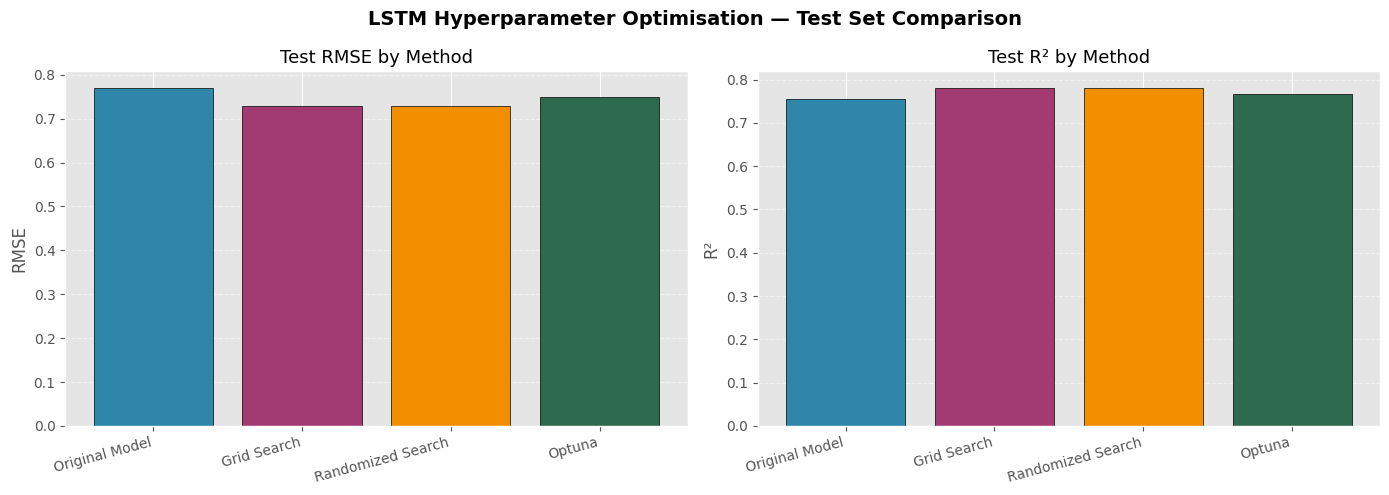

In [13]:
# ── Build the comparison DataFrame ──
methods = ['Original Model', 'Grid Search', 'Randomized Search', 'Optuna']

summary_data = []
for method in methods:
    r = results_store[method]
    summary_data.append({
        'Method'    : method,
        'Train RMSE': round(r['Train RMSE'], 4),
        'Train MAE' : round(r['Train MAE'],  4),
        'Train MAPE': round(r['Train MAPE'], 2),
        'Train R²'  : round(r['Train R2'],   4),
        'Test RMSE' : round(r['Test RMSE'],  4),
        'Test MAE'  : round(r['Test MAE'],   4),
        'Test MAPE' : round(r['Test MAPE'],  2),
        'Test R²'   : round(r['Test R2'],    4)
    })

summary_df = pd.DataFrame(summary_data)

# ── Pretty-print with tabulate ──
print('\n' + '=' * 80)
print('  LSTM PERFORMANCE SUMMARY — DATASET 1')
print('  (80% Train / 20% Test  |  TimeSeriesSplit CV on train only)')
print('=' * 80)
print(tabulate(summary_df, headers='keys', tablefmt='grid',
               showindex=False, floatfmt='.4f'))

# ── Display as styled pandas table ──
display(summary_df.style
        .set_caption('LSTM — Hyperparameter Optimisation Comparison (Dataset 1)')
        .highlight_min(subset=['Test RMSE', 'Test MAE', 'Test MAPE'], color='lightgreen')
        .highlight_max(subset=['Test R²'],                             color='lightgreen')
        .format({
            'Train RMSE': '{:.4f}', 'Train MAE': '{:.4f}',
            'Train MAPE': '{:.2f}', 'Train R²' : '{:.4f}',
            'Test RMSE' : '{:.4f}', 'Test MAE' : '{:.4f}',
            'Test MAPE' : '{:.2f}', 'Test R²'  : '{:.4f}'
        })
)

# ── Bar chart comparison (Test RMSE and Test R²) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#2D6A4F']

axes[0].bar(summary_df['Method'], summary_df['Test RMSE'], color=colors, edgecolor='black')
axes[0].set_title('Test RMSE by Method', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(summary_df['Method'], rotation=15, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(summary_df['Method'], summary_df['Test R²'], color=colors, edgecolor='black')
axes[1].set_title('Test R² by Method', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].set_xticklabels(summary_df['Method'], rotation=15, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('LSTM Hyperparameter Optimisation — Test Set Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()